In [3]:
!pip install split-folders

In [4]:
import splitfolders

DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\Flower_Image_Classification\Image"

splitfolders.ratio(
    DATA_DIR,
    output="dataset_split",
    seed=42,
    ratio=(.7, .15, .15)
)


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report


In [6]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_dir = "dataset_split/train"
val_dir   = "dataset_split/val"
test_dir  = "dataset_split/test"


In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)


Found 3019 files belonging to 5 classes.
Found 644 files belonging to 5 classes.
Found 654 files belonging to 5 classes.
Classes: ['Rose', 'Sun Flower', 'Tulip', 'daisy', 'dandelion']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


C:\Users\hp\AppData\Local\Temp\ipykernel_19496\4029109844.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 131s 14us/step


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ sequential (Sequential)       │ (None, 180, 180, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ rescaling (Rescaling)         │ (None, 180, 180, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ mobilenetv2_1.00_224          │ (None, 6, 6, 1280)    │    2,257,984 │
│ (Functional)                  │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling2d      │ (None, 1280)          │            0 │
│ (GlobalAveragePooling2D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 128)           │      163,968 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 5)             │          645 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 66s 488ms/step - accuracy: 0.6605 - loss: 0.9017 - val_accuracy: 0.8276 - val_loss: 0.4793
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - accuracy: 0.7873 - loss: 0.5703 - val_accuracy: 0.8354 - val_loss: 0.4624
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - accuracy: 0.8175 - loss: 0.4973 - val_accuracy: 0.8571 - val_loss: 0.4126
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 439ms/step - accuracy: 0.8394 - loss: 0.4439 - val_accuracy: 0.8602 - val_loss: 0.4126
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 73s 769ms/step - accuracy: 0.8460 - loss: 0.4047 - val_accuracy: 0.8680 - val_loss: 0.3884
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 439ms/step - accuracy: 0.8440 - loss: 0.4018 - val_accuracy: 0.8680 - val_loss: 0.3947
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.8523 - loss: 0.3738 - val_accuracy: 0.8602 - val_loss: 0.4060
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.8678 - loss: 0.3551 - val_accu

In [13]:
test_loss, test_acc = model.evaluate(test_ds)

print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)


21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - accuracy: 0.8853 - loss: 0.3212

Test Accuracy: 0.8853210806846619
Test Loss: 0.32121777534484863


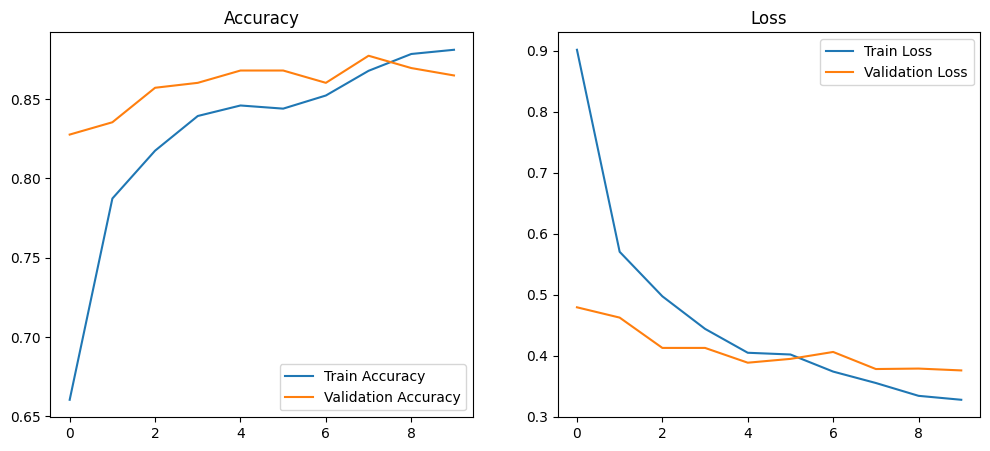

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 332ms/step
              precision    recall  f1-score   support

        Rose       0.87      0.83      0.85       119
  Sun Flower       0.79      0.93      0.85       111
       Tulip       0.90      0.86      0.88       149
       daisy       0.91      0.91      0.91       116
   dandelion       0.95      0.91      0.93       159

    accuracy                           0.89       654
   macro avg       0.88      0.89      0.88       654
weighted avg       0.89      0.89      0.89       654



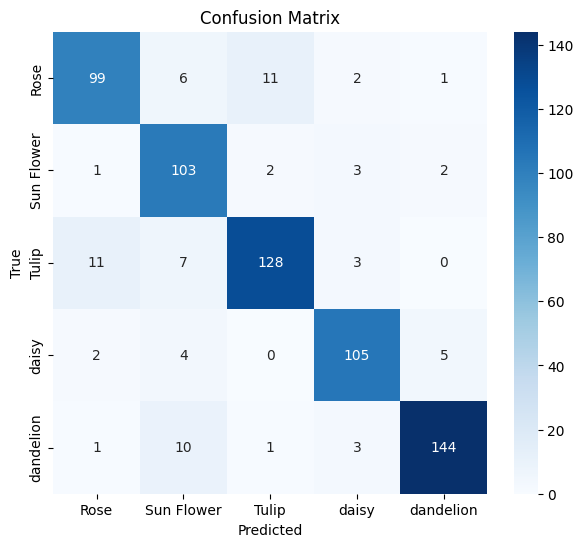

In [18]:
y_test = np.concatenate(
    [labels.numpy() for images, labels in test_ds],
    axis=0
)

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names
))

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()












In [16]:
model.save("trained_model.h5")